In [1]:
import glob
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
import numpy as np
import pandas as pd
import xarray as xr
from scipy.stats import genextreme as gev
import cmdline_provenance as cmdprov

from unseen import fileio
from unseen import array_handling
from unseen import process_utils
from unseen import eva
from unseen import stability
from unseen import independence
from unseen import bias_correction
from unseen import time_utils
from unseen import general_utils
#from unseen import moments
from unseen import similarity
from unseen import spatial_selection

In [2]:
model = 'EC-Earth3'
var = 'tasmax'
levels_dict = {}
levels_dict[var] = np.arange(0, 51, 5)
levels_dict['psl'] = np.arange(900, 1100, 3)
levels_dict['zg500'] = np.arange(5000, 6300, 50)
var_cmap = 'hot_r'
metric = 'TXx'
metric_long = 'hottest day of the year'
units = 'degC'
units_dict = {}
units_dict[var] = units
units_dict['psl'] = 'hPa'
units_dict['zg500'] = 'm'
baseline_period = ['1970-01-01', '2017-12-30'] 
correction_method = 'additive'

region_name = 'NorthAmerica'
region_lat0 = 30  #30N
region_lat1 = 70  #70N
region_lon0 = 180 #180W
region_lon1 = 300 #60W

#map_proj = ccrs.PlateCarree(central_longitude=180)
map_proj = ccrs.LambertConformal(
    central_longitude=240,
    central_latitude=50,
)

box_name = 'PNW heatwave region'
box_lat0 = 45
box_lat1 = 52
box_lon0 = 237
box_lon1 = 241

dist_min = 25
dist_max = 40

outdir = '/g/data/xv83/unseen-projects/outputs/wcrp-txx/data'
obs_file = f'{outdir}/txx_ERA5_1940-2025_annual_PNW.nc'
model_file = f'{outdir}/txx_EC-Earth3-dcppA-hindcast_196011-201711_annual_PNW.nc'

annual_infile_dict = {}
annual_infile_dict[var] = f'{outdir}/{var}-june-july_EC-Earth3-dcppA-hindcast_196011-201711_annual_north-america.nc'
annual_infile_dict['psl'] = f'{outdir}/psl-june-july_EC-Earth3-dcppA-hindcast_196011-201711_annual_north-america.nc'
#annual_infile_dict['zg500'] = f'{outdir}/zg500-june-july_EC-Earth3-dcppA-hindcast_196011-201711_annual_north-america.nc'

code_url = 'https://github.com/AusClimateService/unseen-projects/tree/master/project-wcrp-txx'
history_log = cmdprov.new_log(code_url=code_url)

In [3]:
baseline_start = baseline_period[0][0:4]
baseline_end = baseline_period[1][0:4]

In [4]:
def get_encoding(ds, var):
    """Output file encoding."""

    encoding = {}
    ds_vars = list(ds.coords) + list(ds.keys())
    for ds_var in ds_vars:
        encoding[ds_var] = {'_FillValue': None}

    return encoding

In [5]:
def likelihood(data, event):
    """Calculate event likelihood"""

    shape, loc, scale = eva.fit_gev(data)
    probability = gev.sf(event, shape, loc=loc, scale=scale)
    return_period = 1. / probability
    percentile = (1 - probability) * 100
    print(f'{return_period:.0f} year return period')
    print(f'{percentile:.2f}% percentile')

    return shape, loc, scale

## Read observations

In [6]:
obs_ds = fileio.open_dataset(obs_file)
obs_ds = obs_ds.dropna("time")

In [7]:
obs_max_event = obs_ds[var].values.max()
print(obs_max_event)

39.51474681653524


In [8]:
obs_ds_baseline = time_utils.select_time_period(obs_ds, baseline_period)

## Read (and test) model data

In [9]:
model_ds = fileio.open_dataset(model_file)

In [10]:
model_ds = model_ds.compute()
model_ds

<xarray.Dataset> Size: 423kB
Dimensions:     (init_date: 58, ensemble: 15, lead_time: 10)
Coordinates:
    event_time  (init_date, ensemble, lead_time) <U10 348kB '1961-08-29' ... ...
  * ensemble    (ensemble) int64 120B 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14
  * lead_time   (lead_time) int64 80B 0 1 2 3 4 5 6 7 8 9
  * init_date   (init_date) object 464B 1961-11-01 00:00:00 ... 2018-11-01 00...
    time        (lead_time, init_date) object 5kB 1961-11-01 00:00:00 ... 202...
Data variables:
    tasmax      (init_date, ensemble, lead_time) float64 70kB 32.09 ... 30.91
Attributes: (12/49)
    Conventions:               CF-1.7 CMIP-6.2
    activity_id:               DCPP
    branch_method:             no parent
    branch_time:               0.0
    branch_time_in_child:      0.0
    branch_time_in_parent:     0.0
    ...                        ...
    variant_info:              Atmosphere initialization based on full-fields...
    nominal_resolution:        100 km
    sub_experiment:            initialized near end of year 1960
    sub_experiment_id:         s1960
    history:                   Tue Aug 18 08:19:55 2026: /g/data/xv83/dbi599/...
    NCO:                       netCDF Operators version 4.9.2 (Homepage = htt...

#### Stability and stationarity

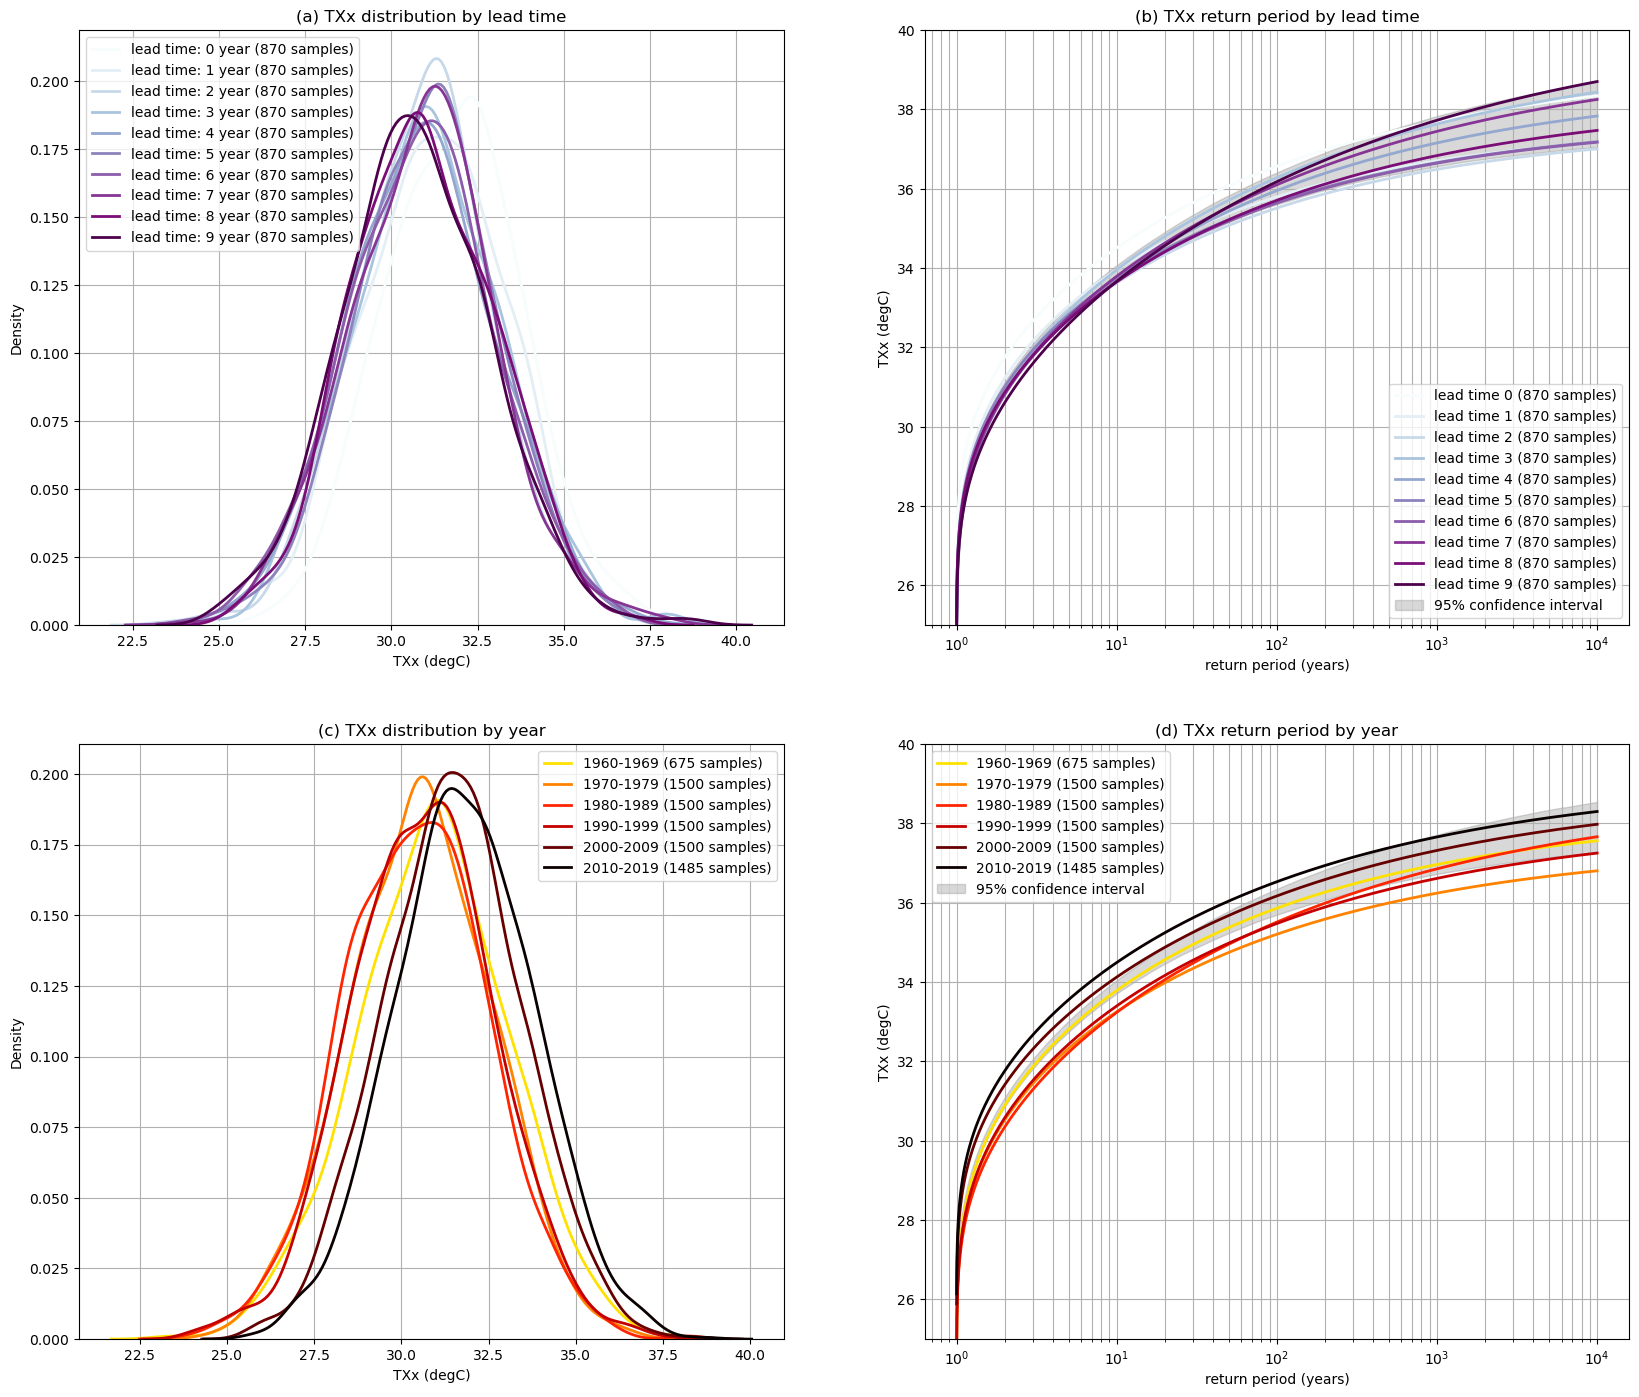

In [11]:
stability.create_plot(
    model_ds[var],
    metric,
    [1960, 1970, 1980, 1990, 2000, 2010],
    uncertainty=True,
    return_method='gev',
    units=f'{metric} ({units})',
    ylim=(dist_min, dist_max),
)

#### Independence

In [12]:
independence_ds = independence.run_tests(model_ds[var])

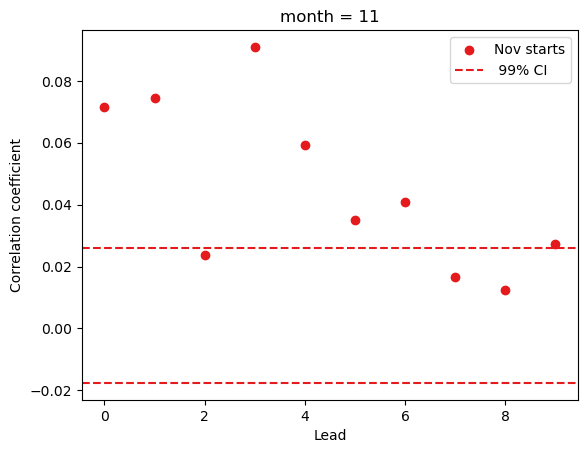

In [13]:
independence.point_plot(
    independence_ds,
    confidence_interval=0.99,
)

In [14]:
min_lead = 2

Drop lead times that aren't independent...

In [15]:
model_da_indep = model_ds[var].where(model_ds['lead_time'] >= min_lead)
model_da_indep = model_da_indep.dropna('lead_time')

In [16]:
model_da_indep_stacked = model_da_indep.stack({'sample': ['ensemble', 'init_date', 'lead_time']})

In [17]:
model_da_indep_baseline = time_utils.select_time_period(model_da_indep, baseline_period)
model_da_indep_baseline_stacked = model_da_indep_baseline.stack({'sample': ['ensemble', 'init_date', 'lead_time']})

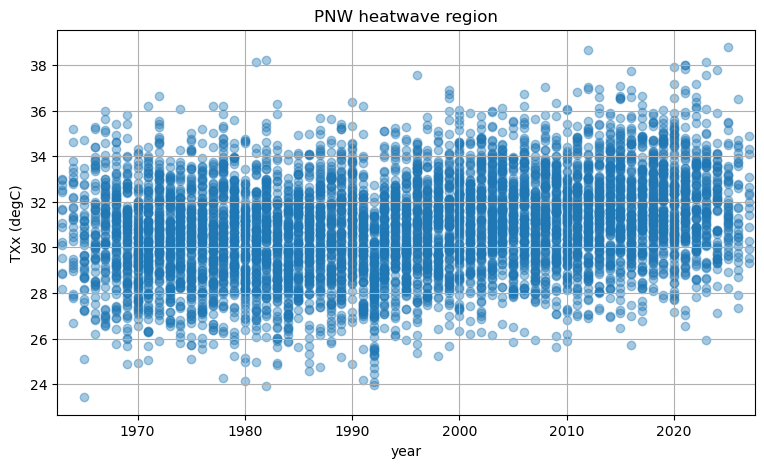

In [18]:
fig, ax = plt.subplots(figsize=[9, 5])
years = model_da_indep_stacked['time'].dt.year.values
unique_years = np.unique(model_da_indep_stacked.time.dt.year.values)

plt.scatter(
    years,
    model_da_indep_stacked.values,
    marker='o',
    color='tab:blue',
    alpha=0.4,
    label='raw data'
)
plt.xlim(unique_years[0] - 0.5, unique_years[-1] + 0.5)
plt.title(box_name)
plt.ylabel(f'{metric} ({units})')
plt.xlabel('year')
#plt.legend()
plt.grid()
plt.show()

#### Bias correction

In [19]:
bias = bias_correction.get_bias(
    model_da_indep,
    obs_ds[var],
    correction_method,
    time_rounding='A',
    time_period=baseline_period
)
print(bias)

<xarray.DataArray 'tasmax' (month: 1)> Size: 8B
dask.array<subtract, shape=(1,), dtype=float64, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
  * month    (month) int64 8B 11
Attributes:
    standard_name:           air_temperature
    long_name:               Daily Maximum Near-Surface Air Temperature
    comment:                 maximum near-surface (usually, 2 meter) air temp...
    units:                   °C
    cell_methods:            area: mean time: maximum
    cell_measures:           area: areacella
    history:                 2019-03-20T07:54:27Z altered by CMOR: Treated sc...
    units_metadata:          temperature: unknown
    climatological_period:   ['1970-01-01', '2017-12-30']
    bias_correction_method:  additive
    bias_correction_period:  1970-01-01-2017-12-30


In [20]:
bias_value = bias.values[0]
print(bias_value)

-0.059148136541008256


In [21]:
model_da_bc = bias_correction.remove_bias(model_da_indep, bias, correction_method)

In [22]:
model_da_bc = model_da_bc.compute()

In [23]:
model_da_bc_stacked = model_da_bc.stack({'sample': ['ensemble', 'init_date', 'lead_time']})

In [24]:
model_da_bc_baseline = time_utils.select_time_period(model_da_bc, baseline_period)
model_da_bc_baseline_stacked = model_da_bc_baseline.stack({'sample': ['ensemble', 'init_date', 'lead_time']})

#### Similarity testing

In [25]:
def plot_dist(time_period='full'):
    """Plot distribution."""

    assert time_period in ['full', 'baseline']

    fig, ax = plt.subplots(figsize=[8, 5])
    xvals = np.arange(dist_min, dist_max, 0.1)

    if time_period == 'baseline':
        title = f'{box_name} - comparison period ({baseline_start}-{baseline_end})'
        model_da_indep_baseline.plot.hist(bins=20, density=True, alpha=0.7, facecolor='tab:blue')
        model_raw_shape, model_raw_loc, model_raw_scale = eva.fit_gev(model_da_indep_baseline_stacked.values, use_basinhopping=True)
        model_da_bc_baseline.plot.hist(bins=50, density=True, alpha=0.7, facecolor='tab:orange')
        model_bc_shape, model_bc_loc, model_bc_scale = eva.fit_gev(model_da_bc_baseline_stacked.values, use_basinhopping=True)
        obs_ds_baseline[var].plot.hist(ax=ax, bins=50, density=True, facecolor='tab:gray', alpha=0.7)
        obs_shape, obs_loc, obs_scale = eva.fit_gev(obs_ds_baseline[var].values, use_basinhopping=True)
    else:
        title = f'{box_name} - full timeseries'
        model_da_indep.plot.hist(bins=20, density=True, alpha=0.7, facecolor='tab:blue')
        model_raw_shape, model_raw_loc, model_raw_scale = eva.fit_gev(model_da_indep_stacked.values, use_basinhopping=True)
        model_da_bc.plot.hist(bins=50, density=True, alpha=0.7, facecolor='tab:orange')
        model_bc_shape, model_bc_loc, model_bc_scale = eva.fit_gev(model_da_bc_stacked.values, use_basinhopping=True)
        obs_ds[var].plot.hist(ax=ax, bins=50, density=True, facecolor='tab:gray', alpha=0.7)
        obs_shape, obs_loc, obs_scale = eva.fit_gev(obs_ds[var].values, use_basinhopping=True)
    
    model_raw_pdf = gev.pdf(xvals, model_raw_shape, model_raw_loc, model_raw_scale)
    plt.plot(xvals, model_raw_pdf, color='tab:blue', linewidth=4.0, label='model')
    
    model_bc_pdf = gev.pdf(xvals, model_bc_shape, model_bc_loc, model_bc_scale)
    plt.plot(xvals, model_bc_pdf, color='tab:orange', linewidth=4.0, label='model (corrected)')
    
    obs_pdf = gev.pdf(xvals, obs_shape, obs_loc, obs_scale)
    plt.plot(xvals, obs_pdf, color='tab:gray', linewidth=4.0, label='ERA5')
    
    plt.xlabel(f'{metric} ({units})')
    plt.ylabel('probability')
    plt.title(title)
    plt.xlim(dist_min, dist_max)
    plt.legend()
    plt.grid()
    plt.show()

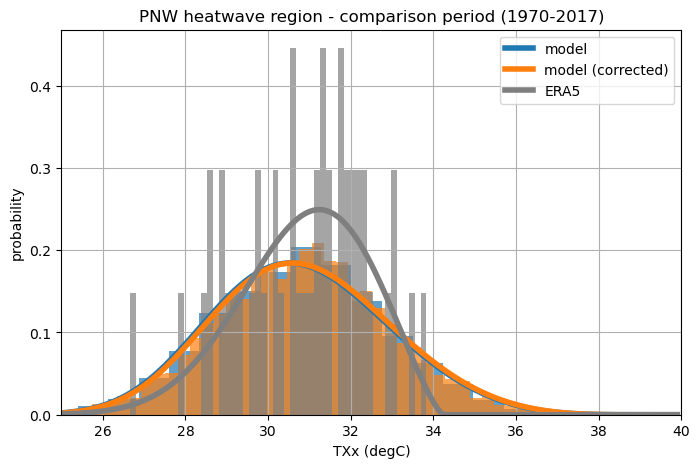

In [26]:
plot_dist(time_period='baseline')

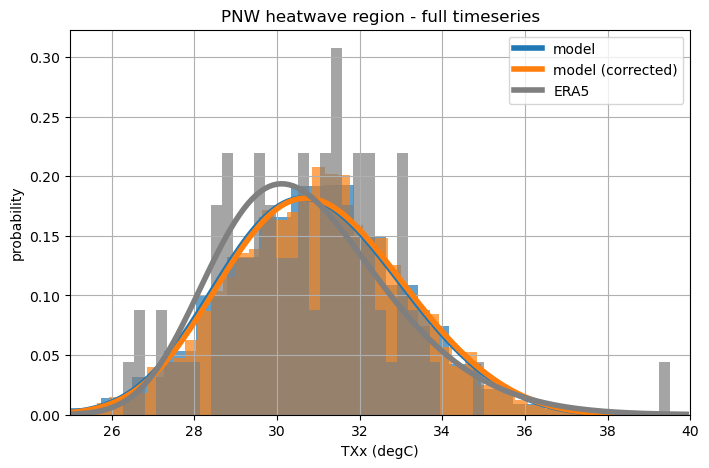

In [27]:
plot_dist(time_period='full')

Since the data has a strong trend with time, the similarity testing is conducted over the time period equally sampled by the observations and model (1970-2017).

In [28]:
#moments.create_plot(
#    model_da_indep_baseline,
#    obs_ds_baseline[var],
#    da_bc_fcst=model_da_bc_baseline,
#)

In [29]:
similarity_ds = similarity.similarity_tests(model_da_indep_baseline, obs_ds_baseline[var])
print('KS score:', similarity_ds['ks_statistic'].values)
print('KS p-value:', similarity_ds['ks_pval'].values)
print('AD score:', similarity_ds['ad_statistic'].values)
print('AD p-value:', similarity_ds['ad_pval'].values)

KS score: 0.09674202
KS p-value: 0.7388342
AD score: 0.068241864
AD p-value: 0.25


In [30]:
similarity_ds = similarity.similarity_tests(model_da_bc_baseline, obs_ds_baseline[var])
print('KS score:', similarity_ds['ks_statistic'].values)
print('KS p-value:', similarity_ds['ks_pval'].values)
print('AD score:', similarity_ds['ad_statistic'].values)
print('AD p-value:', similarity_ds['ad_pval'].values)

KS score: 0.10507535
KS p-value: 0.643287
AD score: -0.013550555
AD p-value: 0.25


p > 0.05 means that the null hypothesis (that the two samples are from the same population) cannot be rejected.

#### Process assessment

In [31]:
def ensemble_to_run(model_name, ensnum):
    """Map ensemble number to DCPP model run"""

    norcpm_dict = {
        1: 'r1i1p1f1',
        2: 'r1i2p1f1',
        3: 'r2i1p1f1',
        4: 'r2i2p1f1',
        5: 'r3i1p1f1',
        6: 'r3i2p1f1',
        7: 'r4i1p1f1',
        8: 'r4i2p1f1',
        9: 'r5i1p1f1',
        10: 'r5i2p1f1',
        11: 'r6i1p1f1',
        12: 'r6i2p1f1',
        13: 'r7i1p1f1',
        14: 'r7i2p1f1',
        15: 'r8i1p1f1',
        16: 'r8i2p1f1',
        17: 'r9i1p1f1',
        18: 'r9i2p1f1',
        19: 'r10i1p1f1',
        20: 'r10i2p1f1',
    }

    ecearth_dict = {
        1: 'r1i1p1f1',
        2: 'r2i1p1f1',
        3: 'r3i1p1f1',
        4: 'r4i1p1f1',
        5: 'r5i1p1f1',
        6: 'r6i1p1f1',
        7: 'r6i2p1f1',
        8: 'r7i1p1f1',
        9: 'r7i2p1f1',
        10: 'r8i1p1f1',
        11: 'r8i2p1f1',
        12: 'r9i1p1f1',
        13: 'r9i2p1f1',
        14: 'r10i1p1f1',
        15: 'r10i2p1f1',
    }

    if model_name == 'EC-Earth3':
        run = ecearth_dict[ensnum]
    elif model_name == 'NorCPM1':
        run = norcpm_dict[ensnum]
    else:
        ensemble_to_run = { 
            'BCC-CSM2-MR': f'r{ensnum}i1p1f1',
            'CanESM5': f'r{ensnum}i1p2f1',
            'CMCC-CM2-SR5': f'r{ensnum}i1p1f1',
            'HadGEM3-GC31-MM': f'r{ensnum}i1p1f2',
            'IPSL-CM6A-LR': f'r{ensnum}i1p1f1',
            'MIROC6': f'r{ensnum}i1p1f1',
            'MPI-ESM1-2-HR': f'r{ensnum}i1p1f1',
            'MRI-ESM2-0': f'r{ensnum}i1p1f1',
        }
        run = ensemble_to_run[model_name]

    return run
    

def find_dcpp_data(event_df_row, model_name):
    """Find DCPP data for one row of a dataframe of events."""

    init_adjustment = {
        'BCC-CSM2-MR': 0,
        'CanESM5': -1,
        'CMCC-CM2-SR5': -1,
        'EC-Earth3': -1,
        'IPSL-CM6A-LR': -1,
        'MIROC6': -1,
        'MPI-ESM1-2-HR': -1,
        'MRI-ESM2-0': -1,
        'NorCPM1': -1,
    }

    assert model_name in init_adjustment
    
    init_date = int(event_df_row['init_date'].strftime('%Y')) + init_adjustment[model_name]
    ensemble = int(event_df_row['ensemble']) + 1
    run = ensemble_to_run(model_name, ensemble)
    event_date = event_df_row['event_time']
    event_value = round(float(event_df_row[var]), 1)
    event_summary = f'{metric} of {event_value} on {event_date}: initialisation year {init_date}, ensemble member {run}'
    print(event_summary)
    var_files = glob.glob(f'/g/data/oi10/replicas/CMIP6/DCPP/*/{model_name}/dcppA-hindcast/s{init_date}-{run}/day/{var}/*/*/*.nc')
    assert var_files
    psl_files = glob.glob(f'/g/data/oi10/replicas/CMIP6/DCPP/*/{model_name}/dcppA-hindcast/s{init_date}-{run}/day/psl/*/*/*.nc')
    zg500_files = glob.glob(f'/g/data/oi10/replicas/CMIP6/DCPP/*/{model_name}/dcppA-hindcast/s{init_date}-{run}/AERday/zg500/*/*/*.nc')

    return var_files, psl_files, zg500_files, event_date, event_value, event_summary

In [32]:
def event_check(da, event_value):
    """Check the event value"""

    da_box = da.sel(lat=slice(box_lat0, box_lat1), lon=slice(box_lon0, box_lon1))
    da_box_mean = spatial_selection.aggregate(da_box, 'weighted_mean')
    
    np.testing.assert_approx_equal(float(da_box_mean[-1]) - bias_value, event_value, significant=1)
    

def get_start_date(event_date):
    """Get start date."""

    event_datetime = datetime.strptime(event_date, "%Y-%m-%d")
    start_datetime = event_datetime - timedelta(days=4)
    start_date = start_datetime.strftime("%Y-%m-%d")

    return start_date


def to_file_date(selected_date):
    """Convert a YYYY-MM-DD date to YYYYMMDD"""

    selected_datetime = datetime.strptime(selected_date, "%Y-%m-%d")
    selected_filedate = selected_datetime.strftime("%Y%m%d")

    return selected_filedate


def get_outfname(inpath, start_date, end_date):
    """Get output file name."""

    start_filedate = to_file_date(start_date)
    end_filedate = to_file_date(end_date)

    infname = inpath.split('/')[-1]
    fparts = infname.split('_')
    fparts[-1] = f'{start_filedate}-{end_filedate}.nc'
    fparts[-2] = f'{fparts[-2]}-{region_name}'
    outfname = '_'.join(fparts)
    outpath = f'{outdir}/{outfname}'

    return outpath


def thin_attrs(ds, var, unit):
    """Thin the variable attributes"""

    try:
        ds = ds.drop_vars('height')
    except ValueError:
        pass
    
    orig_attrs = ds[var].attrs
    ds[var].attrs = {}
    ds[var].attrs['long_name'] = orig_attrs['long_name']
    ds[var].attrs['standard_name'] = orig_attrs['standard_name']
    ds[var].attrs['units'] = unit

    return ds


def write_outfile(da, var, units, event_summary, infile, start_date, event_date):
    """Write output 5-day data file"""

    output_ds = da.to_dataset()
    output_ds = thin_attrs(output_ds, var, units)
    output_ds.attrs = {
        'description': f'Five days leading up to and including this event - {event_summary}',
        'model': model,
        'history': history_log,
    }
    outfname = get_outfname(infile, start_date, event_date)
    encoding = get_encoding(output_ds, var)
    output_ds.to_netcdf(outfname, encoding=encoding)
    print(outfname)


def get_event_data(event_df_row, model_name, write_to_file=False):
    """Plot an event"""

    infiles_var, infiles_psl, infiles_zg500, event_date, event_value, event_summary = find_dcpp_data(event_df_row, model_name)

    start_date = get_start_date(event_date)

    ds_var = fileio.open_dataset(infiles_var)
    ds_var = ds_var.sel(
        time=slice(start_date, event_date),
        lat=slice(region_lat0 - 5, region_lat1 + 5),
        lon=slice(region_lon0 - 5, region_lon1 + 5),
    )
    da_var = general_utils.convert_units(ds_var[var], units)
    event_check(da_var, event_value)

    if infiles_psl:
        ds_psl = fileio.open_dataset(infiles_psl)
        ds_psl = ds_psl.sel(
            time=slice(start_date, event_date),
            lat=slice(region_lat0 - 5, region_lat1 + 5),
            lon=slice(region_lon0 - 5, region_lon1 + 5),
        )
        da_psl = general_utils.convert_units(ds_psl['psl'], 'hPa')
    else:
        da_psl = None
    
    if infiles_zg500:
        ds_zg500 = fileio.open_dataset(infiles_zg500)
        ds_zg500 = ds_zg500.sel(
            time=slice(start_date, event_date),
            lat=slice(region_lat0 - 5, region_lat1 + 5),
            lon=slice(region_lon0 - 5, region_lon1 + 5),
        )
        da_zg500 = ds_zg500['zg500']
    else:
        da_zg500 = None
    
    if write_to_file:
        write_outfile(da_var, var, units, event_summary, infiles_var[0], start_date, event_date)
        if infiles_psl:
            write_outfile(da_psl, 'psl', 'hPa', event_summary, infiles_psl[0], start_date, event_date)
        if infiles_zg500:
            write_outfile(da_zg500, 'zg500', 'm', event_summary, infiles_zg500[0], start_date, event_date)

    return da_var, da_psl, da_zg500

In [33]:
def plot_event(da_var, da_contour, contour_var):
    """Plot event."""

    assert contour_var in ['psl', 'zg500']
    
    fig = plt.figure(figsize=[15, 5])
    ax = fig.add_subplot(111, projection=map_proj)
    
    da_var.isel(time=4).plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=var_cmap,
        levels=levels_dict[var],
        extend='both',
    #    cbar_kwargs={"label": label},
    )
    if type(da_contour) != type(None):
        lines = da_contour.isel(time=4).plot.contour(
            ax=ax,
            transform=ccrs.PlateCarree(),
            levels=levels_dict[contour_var],
            colors=["0.3"]
        )
        ax.clabel(lines, colors=["0.3"], manual=False, inline=True)
    
    ax.plot(
        [box_lon0, box_lon0, box_lon1, box_lon1, box_lon0],
        [box_lat1, box_lat0, box_lat0, box_lat1, box_lat1],
        transform=ccrs.PlateCarree(),
        color='green',
    )   
    ax.coastlines()
    #ax.set_extent([180, 300, 30, 70], crs=ccrs.PlateCarree(central_longitude=0))
    ax.add_feature(cartopy.feature.BORDERS)
    ax.gridlines(linestyle="--", draw_labels=True)
    
    plt.show()

In [34]:
model_da_bc_stacked_df = model_da_bc_stacked.to_dataframe()
model_da_bc_stacked_df_sorted = model_da_bc_stacked_df.sort_values(by=[var], ascending=False)
model_da_bc_stacked_df_sorted.head(n=5)

,,,event_time,time,ensemble,init_date,lead_time,tasmax
ensemble,init_date,lead_time,,,,,,
14,2016-11-01 00:00:00,9,2025-07-30,2025-11-01 00:00:00,14,2016-11-01 00:00:00,9,38.835990
6,2003-11-01 00:00:00,9,2012-08-10,2012-11-01 00:00:00,6,2003-11-01 00:00:00,9,38.708544
0,1975-11-01 00:00:00,7,1982-08-06,1982-11-01 00:00:00,0,1975-11-01 00:00:00,7,38.276679
8,2014-11-01 00:00:00,9,2023-08-19,2023-11-01 00:00:00,8,2014-11-01 00:00:00,9,38.207258
6,1978-11-01 00:00:00,3,1981-08-16,1981-11-01 00:00:00,6,1978-11-01 00:00:00,3,38.200544


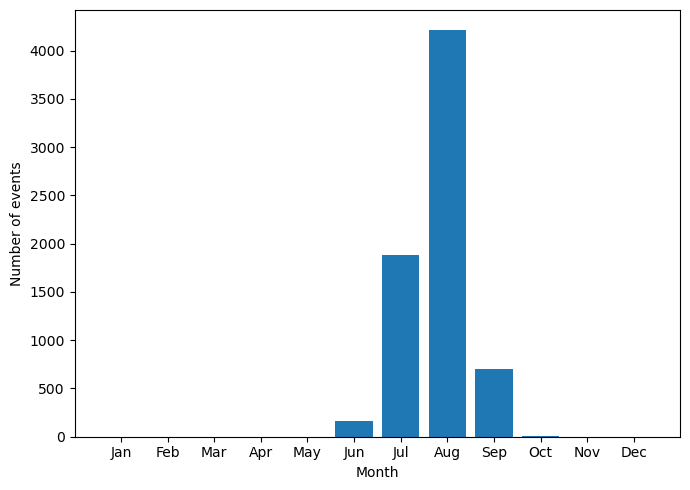

In [35]:
process_utils.plot_event_seasonality(model_da_bc_stacked, core_dim='sample')

TXx of 38.8 on 2025-07-30: initialisation year 2015, ensemble member r10i2p1f1
/g/data/xv83/unseen-projects/outputs/wcrp-txx/data/tasmax_day_EC-Earth3_dcppA-hindcast_s2015-r10i2p1f1_gr-NorthAmerica_20250726-20250730.nc
/g/data/xv83/unseen-projects/outputs/wcrp-txx/data/psl_day_EC-Earth3_dcppA-hindcast_s2015-r10i2p1f1_gr-NorthAmerica_20250726-20250730.nc
/g/data/xv83/unseen-projects/outputs/wcrp-txx/data/zg500_AERday_EC-Earth3_dcppA-hindcast_s2015-r10i2p1f1_gr-NorthAmerica_20250726-20250730.nc


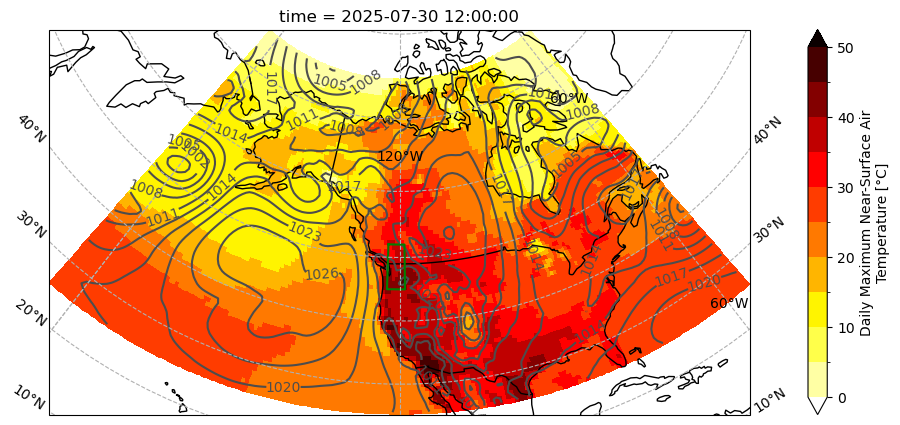

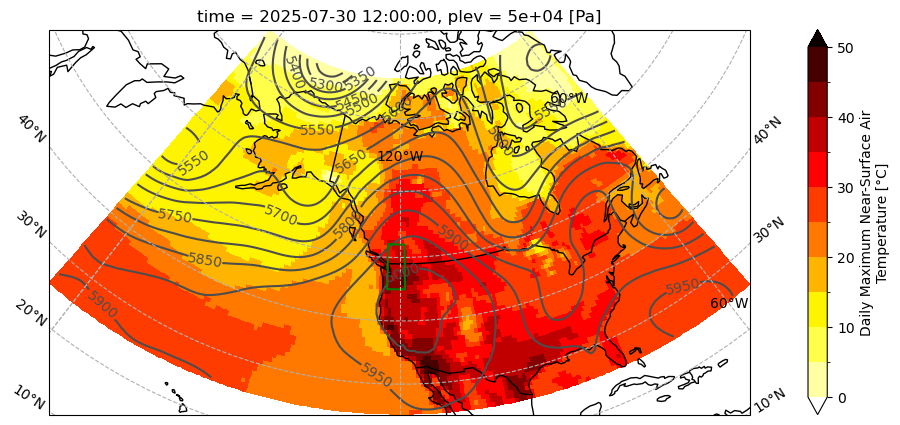

TXx of 38.7 on 2012-08-10: initialisation year 2002, ensemble member r6i2p1f1
/g/data/xv83/unseen-projects/outputs/wcrp-txx/data/tasmax_day_EC-Earth3_dcppA-hindcast_s2002-r6i2p1f1_gr-NorthAmerica_20120806-20120810.nc
/g/data/xv83/unseen-projects/outputs/wcrp-txx/data/psl_day_EC-Earth3_dcppA-hindcast_s2002-r6i2p1f1_gr-NorthAmerica_20120806-20120810.nc
/g/data/xv83/unseen-projects/outputs/wcrp-txx/data/zg500_AERday_EC-Earth3_dcppA-hindcast_s2002-r6i2p1f1_gr-NorthAmerica_20120806-20120810.nc


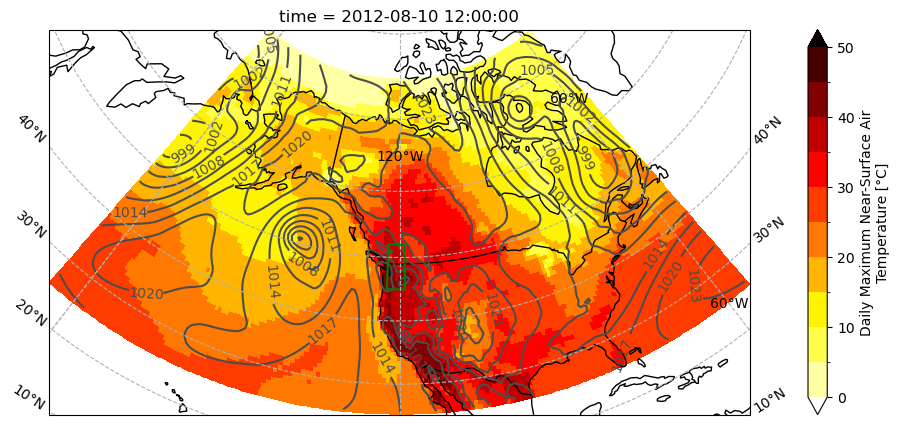

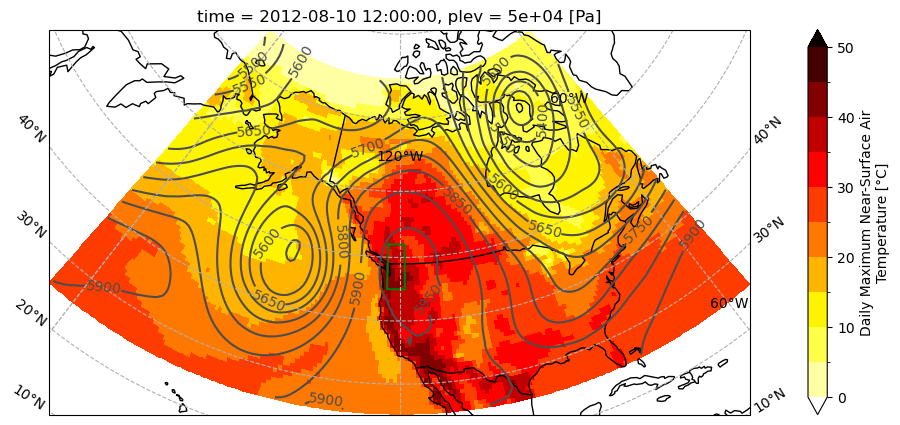

TXx of 38.3 on 1982-08-06: initialisation year 1974, ensemble member r1i1p1f1
/g/data/xv83/unseen-projects/outputs/wcrp-txx/data/tasmax_day_EC-Earth3_dcppA-hindcast_s1974-r1i1p1f1_gr-NorthAmerica_19820802-19820806.nc
/g/data/xv83/unseen-projects/outputs/wcrp-txx/data/psl_day_EC-Earth3_dcppA-hindcast_s1974-r1i1p1f1_gr-NorthAmerica_19820802-19820806.nc
/g/data/xv83/unseen-projects/outputs/wcrp-txx/data/zg500_AERday_EC-Earth3_dcppA-hindcast_s1974-r1i1p1f1_gr-NorthAmerica_19820802-19820806.nc


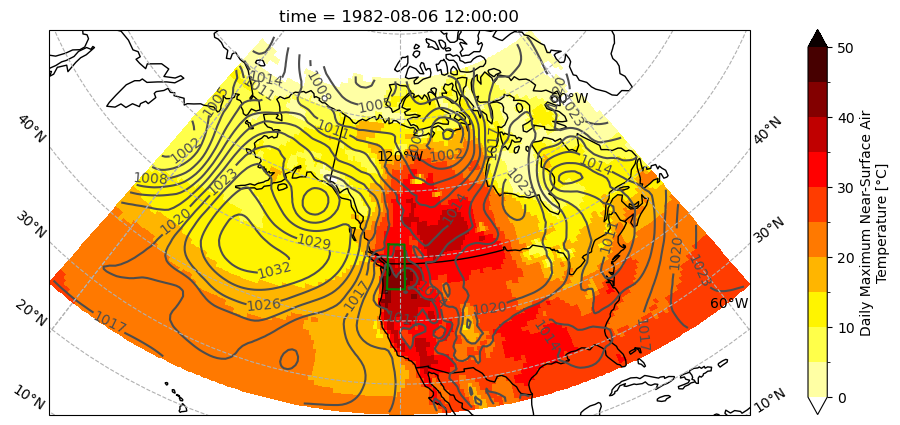

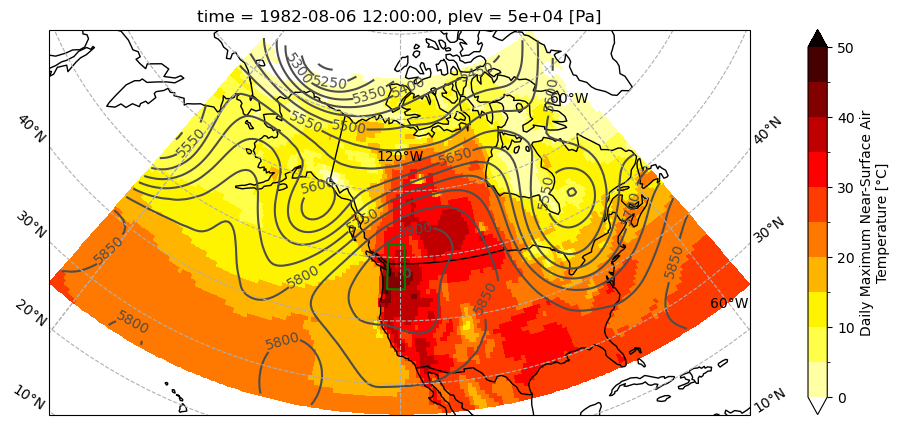

TXx of 38.2 on 2023-08-19: initialisation year 2013, ensemble member r7i2p1f1
/g/data/xv83/unseen-projects/outputs/wcrp-txx/data/tasmax_day_EC-Earth3_dcppA-hindcast_s2013-r7i2p1f1_gr-NorthAmerica_20230815-20230819.nc
/g/data/xv83/unseen-projects/outputs/wcrp-txx/data/psl_day_EC-Earth3_dcppA-hindcast_s2013-r7i2p1f1_gr-NorthAmerica_20230815-20230819.nc
/g/data/xv83/unseen-projects/outputs/wcrp-txx/data/zg500_AERday_EC-Earth3_dcppA-hindcast_s2013-r7i2p1f1_gr-NorthAmerica_20230815-20230819.nc


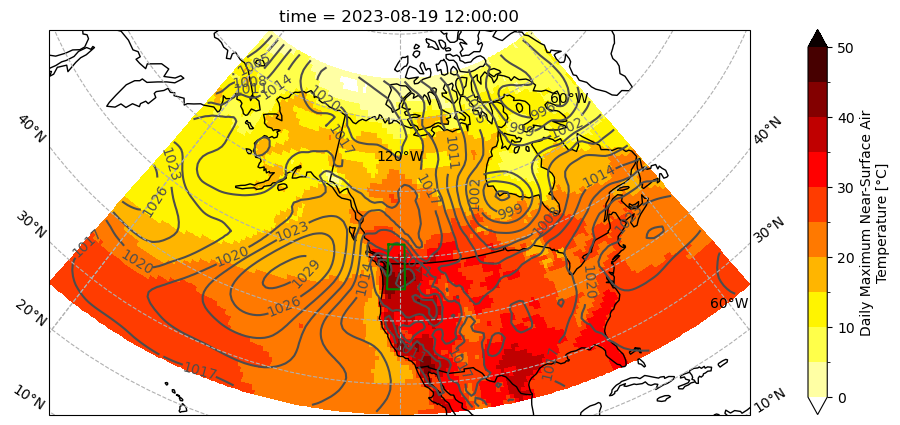

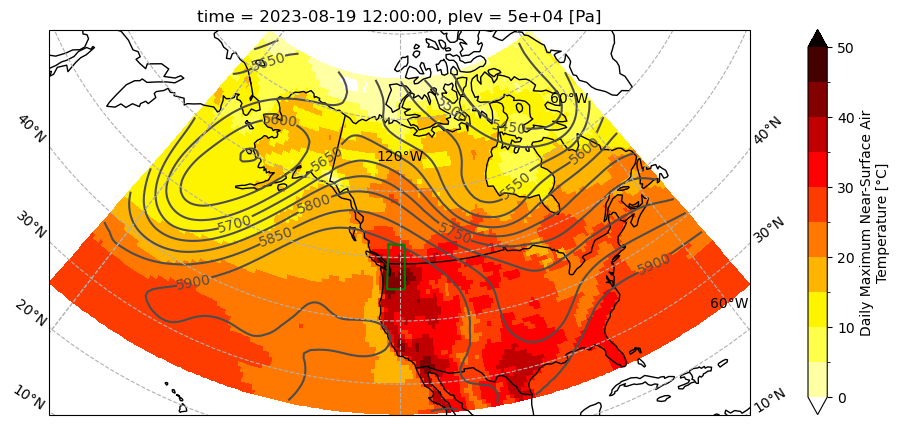

TXx of 38.2 on 1981-08-16: initialisation year 1977, ensemble member r6i2p1f1
/g/data/xv83/unseen-projects/outputs/wcrp-txx/data/tasmax_day_EC-Earth3_dcppA-hindcast_s1977-r6i2p1f1_gr-NorthAmerica_19810812-19810816.nc
/g/data/xv83/unseen-projects/outputs/wcrp-txx/data/psl_day_EC-Earth3_dcppA-hindcast_s1977-r6i2p1f1_gr-NorthAmerica_19810812-19810816.nc
/g/data/xv83/unseen-projects/outputs/wcrp-txx/data/zg500_AERday_EC-Earth3_dcppA-hindcast_s1977-r6i2p1f1_gr-NorthAmerica_19810812-19810816.nc


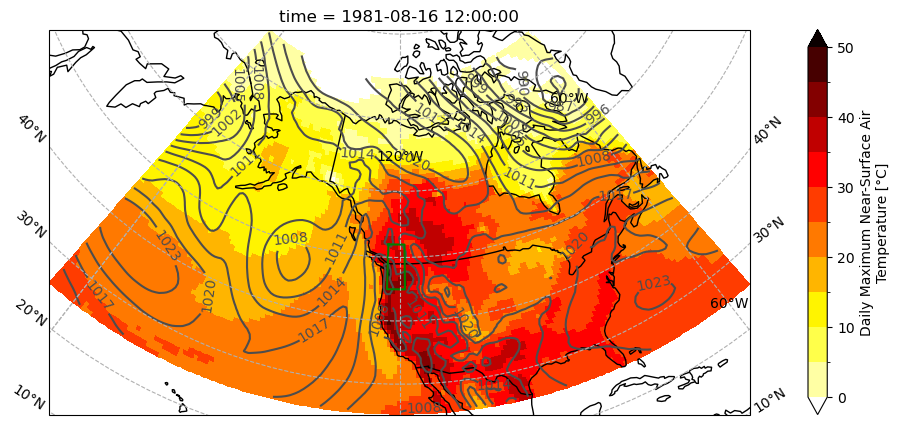

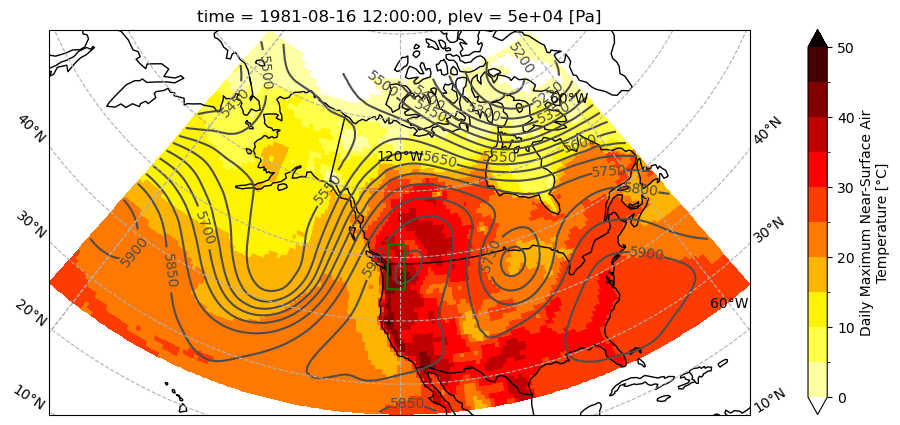

In [36]:
for event in range(5):
    da_var, da_psl, da_zg500 = get_event_data(
        model_da_bc_stacked_df_sorted.iloc[event],
        model,
        write_to_file=True
    )
    plot_event(da_var, da_psl, 'psl')
    plot_event(da_var, da_zg500, 'zg500')

## Results

In [37]:
def write_samples(input_da, model, dtype):
    """Write samples to file."""

    assert dtype in ['bias corrected', 'raw']
    
    nsamples = len(input_da)
    numbers = list(np.arange(nsamples) + 1)
    output_da = xr.DataArray(
        data=np.round(input_da.values, 2),
        coords={'number': numbers,},
        name=metric,
        attrs = {
            'long_name': metric_long,
            'units': units,
        }
    )
    output_ds = output_da.to_dataset()
    output_ds.attrs = {
        'description': f'{dtype} samples',
        'model': model,
        'history': history_log,
    }
    
    fname_dtype = dtype.replace(' ', '-')
    fname = f'{outdir}/{metric.lower()}_{model}_{fname_dtype}.nc'
    encoding = get_encoding(output_ds, metric)
    output_ds.to_netcdf(fname, encoding=encoding)
    print(fname)

In [38]:
write_samples(model_da_bc_stacked, model, 'bias corrected')

/g/data/xv83/unseen-projects/outputs/wcrp-txx/data/txx_EC-Earth3_bias-corrected.nc


In [39]:
write_samples(model_da_indep_stacked, model, 'raw')

/g/data/xv83/unseen-projects/outputs/wcrp-txx/data/txx_EC-Earth3_raw.nc


#### Non-stationary GEV

In [40]:
#AIC/BIC/LRT test to see if it's worth modelling the scale trend
daparams_list = [eva.fit_gev(
    model_da_bc_stacked,
    core_dim="sample",
    stationary=False,
    covariate=model_da_bc_stacked['time'].dt.year,
    use_basinhopping=True,
    scale1=scale1,
).values for scale1 in [0, None]]

data = model_da_bc_stacked.values
covariate = model_da_bc_stacked['time'].dt.year.values
nll_1 = eva._gev_nllf(daparams_list[0], data, covariate)
nll_2 = eva._gev_nllf(daparams_list[1], data, covariate)
result = eva.check_gev_relative_fit(data, nll_1, nll_2, test='bic', n_params=[4,5])
print('better to include the scale trend parameter:', result)

better to include the scale trend parameter: False


In [41]:
daparams = eva.fit_gev(
    model_da_bc_stacked,
    core_dim="sample",
    stationary=False,
    covariate=model_da_bc_stacked['time'].dt.year,
    use_basinhopping=True,
    scale1=None,
)

In [42]:
for param, value in zip(daparams.dparams.values, daparams.values):
    print(param, value)

c 0.22741370749413137
location_0 -35.588129663198515
location_1 0.03297427068047129
scale_0 2.0059683451506887
scale_1 0.0


In [43]:
return_period = float(eva.get_return_period(obs_max_event, daparams, covariate=2021).values)

In [44]:
# parametric uncertainty estimate
n_bootstraps = 1000
shape, loc, scale = eva.unpack_gev_params(daparams, 2021)
sample_size = len(model_da_bc_stacked)
boot_samples = []
for i in range(n_bootstraps):
    boot_data = gev.rvs(float(shape), loc=float(loc), scale=float(scale), size=sample_size)
    boot_gev_params = eva.fit_gev(boot_data)
    boot_return_period = eva.get_return_period(obs_max_event, boot_gev_params)
    boot_samples.append(boot_return_period)
lower_ci = np.percentile(boot_samples, 5)
upper_ci = np.percentile(boot_samples, 95)

In [45]:
print(f'The return period of a {obs_max_event:.2f} {units} event in 2021 is {return_period:.0f} years.')
print(f'The 90% confidence interval is {lower_ci:.0f} to {upper_ci:.0f} years.')

The return period of a 39.51 degC event in 2021 is 1301620 years.
The 90% confidence interval is 122145 to 83576825979316 years.


In [46]:
for year in np.arange(1960, 2030):
    rp = float(eva.get_return_period(obs_max_event, daparams, covariate=year).values)
    print(f'The return period of a {obs_max_event:.2f} {units} event in {year} is {rp:.0f} years.')

The return period of a 39.51 degC event in 1960 is inf years.
The return period of a 39.51 degC event in 1961 is inf years.
The return period of a 39.51 degC event in 1962 is inf years.
The return period of a 39.51 degC event in 1963 is inf years.
The return period of a 39.51 degC event in 1964 is inf years.
The return period of a 39.51 degC event in 1965 is inf years.
The return period of a 39.51 degC event in 1966 is inf years.
The return period of a 39.51 degC event in 1967 is inf years.
The return period of a 39.51 degC event in 1968 is inf years.
The return period of a 39.51 degC event in 1969 is inf years.
The return period of a 39.51 degC event in 1970 is inf years.
The return period of a 39.51 degC event in 1971 is inf years.
The return period of a 39.51 degC event in 1972 is inf years.
The return period of a 39.51 degC event in 1973 is inf years.
The return period of a 39.51 degC event in 1974 is inf years.
The return period of a 39.51 degC event in 1975 is inf years.
The retu

### Supporting data

They ask for the June-July climatology for the 1991-2020 period.

In [47]:
ds_annual_dict = {}
ds_annual_dict[var] = fileio.open_dataset(annual_infile_dict[var])
ds_annual_dict['psl'] = fileio.open_dataset(annual_infile_dict['psl'])
#ds_clim_dict['zg500'] = fileio.open_dataset(annual_infile_dict['zg500'])

In [48]:
def calc_clim(ds, clim_var):
    """Calculate climatology"""

    ds = ds.compute()
    ds[var] = general_utils.convert_units(ds[clim_var], units_dict[clim_var])
    ds = array_handling.reindex_forecast(ds)
    da_baseline = ds[clim_var].sel(time=slice('1991-01-01', '2020-12-31'))
    da_clim = da_baseline.mean(dim=['time', 'init_date', 'ensemble'])

    return da_clim

In [49]:
clim_dict = {}
clim_dict[var] = calc_clim(ds_annual_dict[var], var)
clim_dict['psl'] = calc_clim(ds_annual_dict['psl'], 'psl')
#clim_dict['zg500'] = calc_clim(ds_annual_dict['zg500'], 'zg500')

In [50]:
def plot_climatology(contour_var):
    """Plot the climatology"""

    fig = plt.figure(figsize=[15, 5])
    ax = fig.add_subplot(111, projection=map_proj)

    clim_dict[var].plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=var_cmap,
        levels=levels_dict[var],
    )
    lines = clim_dict[contour_var].plot.contour(
        ax=ax,
        transform=ccrs.PlateCarree(),
        levels=levels_dict[contour_var],
        colors=["0.3"]
    )
    ax.clabel(lines, colors=["0.3"], manual=False, inline=True)
    
    ax.coastlines()
    ax.add_feature(cartopy.feature.BORDERS)
    ax.gridlines(linestyle="--", draw_labels=True)
    
    plt.title('1991-2020 climatology (June-July)')
    plt.show()

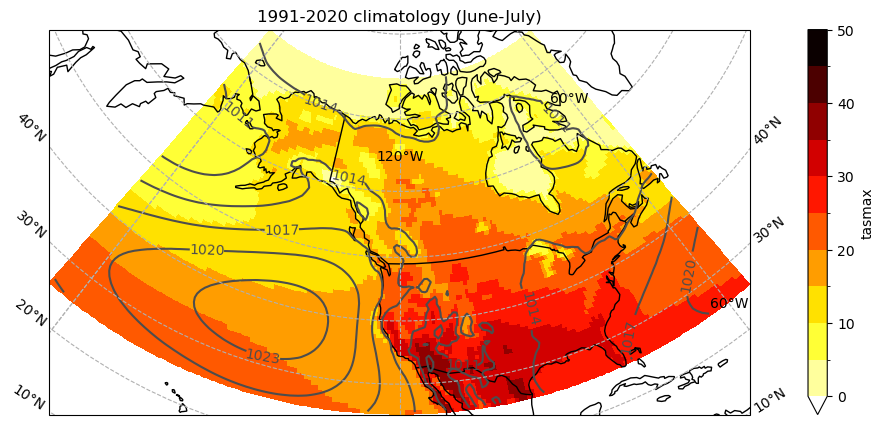

In [51]:
plot_climatology('psl')

In [52]:
#plot_climatology('zg500')

In [53]:
def add_clim_attrs(da_clim, clim_var):
    """Add climatology file attributes"""

    ds = da_clim.to_dataset()
    orig_ds = ds_annual_dict[clim_var]
    
    ds[clim_var].attrs['long_name'] = orig_ds[clim_var].attrs['long_name']
    ds[clim_var].attrs['standard_name'] = orig_ds[clim_var].attrs['standard_name']
    ds[clim_var].attrs['units'] = units_dict[clim_var]

    ds.attrs = {
        'description': '1991-2020 climatology (June-July)',
        'model': model,
        'history': history_log,
    }

    return ds

In [54]:
def get_clim_fname(annual_path):
    """Get output climatology file name."""

    infname = annual_path.split('/')[-1]
    fparts = infname.split('_')
    fparts[-3] = '1991-2020'
    fparts[-2] = 'climatology'
    outfname = '_'.join(fparts)
    outpath = f'{outdir}/{outfname}'

    return outpath

In [55]:
for clim_var in ['tasmax', 'psl']:
    output_ds = add_clim_attrs(clim_dict[clim_var], clim_var)
    fname = get_clim_fname(annual_infile_dict[clim_var])
    encoding = get_encoding(output_ds, clim_var)
    output_ds.to_netcdf(fname, encoding=encoding)
    print(fname)

/g/data/xv83/unseen-projects/outputs/wcrp-txx/data/tasmax-june-july_EC-Earth3-dcppA-hindcast_1991-2020_climatology_north-america.nc
/g/data/xv83/unseen-projects/outputs/wcrp-txx/data/psl-june-july_EC-Earth3-dcppA-hindcast_1991-2020_climatology_north-america.nc
